Fraud Detection - Production Grade Pipeline
============================================
Reusable functions for:
- Data loading & validation
- EDA
- Train/test split
- Pipeline creation (ColumnTransformer + XGBoost)
- Hyperparameter tuning
- Evaluation
- SHAP explainability
- Model saving & loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import joblib
from datetime import datetime

In [2]:
def get_engine():
    """Create SQL Server connection engine."""
    from sqlalchemy import create_engine

    engine = create_engine(
        "mssql+pyodbc://@ALLEN-TIDER/CREDT_SCORE?"
        "driver=ODBC+Driver+17+for+SQL+Server"
        "&trusted_connection=yes"
    )
    return engine

In [3]:
def fetch_data(query):
    """
    Fetch data from SQL Server.

    Args:
        query (str): SQL query

    Returns:
        pd.DataFrame or None
    """
    try:
        engine = get_engine()
        df = pd.read_sql(query, engine)
        print(f"Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
        return df
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

In [4]:
query = "SELECT * FROM dbo.creditcard_data"
df = fetch_data(query)

Data loaded: 284807 rows, 31 columns


In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


SECTION 2: DATA VALIDATION & QUALITY CHECKS

In [6]:
def validate_data(df, target_col="Class"):
    """
    Run data quality checks. Call this immediately after loading.

    Args:
        df (pd.DataFrame): Raw dataframe
        target_col (str): Target column name

    Returns:
        dict: Quality report
    """
    report = {
        "shape": df.shape,
        "columns": df.columns.tolist(),
        "dtypes": df.dtypes.to_dict(),
        "missing_values": df.isnull().sum().to_dict(),
        "total_missing": int(df.isnull().sum().sum()),
        "duplicates": int(df.duplicated().sum()),
        "target_distribution": df[target_col].value_counts(normalize=True).to_dict(),
    }

    print(f"Shape: {report['shape']}")
    print(f"Missing values: {report['total_missing']}")
    print(f"Duplicates: {report['duplicates']}")
    print(f"Target distribution:\n{df[target_col].value_counts(normalize=True)}")

    return report


SECTION 3: DATA CLEANING (Safe before split — no stats learned)

In [7]:
def clean_data(df, drop_cols=None):
    """
    Clean data: drop columns, remove duplicates, fix types.
    These operations are safe BEFORE splitting (no statistics learned).

    Args:
        df (pd.DataFrame): Input dataframe
        drop_cols (list): Columns to drop

    Returns:
        pd.DataFrame: Cleaned dataframe
    """
    initial_shape = df.shape

    # Drop specified columns
    if drop_cols:
        existing = [c for c in drop_cols if c in df.columns]
        df = df.drop(columns=existing)
        print(f"Dropped columns: {existing}")

    # Remove duplicates
    dup_count = df.duplicated().sum()
    if dup_count > 0:
        df = df.drop_duplicates()
        print(f"Removed {dup_count} duplicate rows")

    # Ensure Amount is numeric
    if "Amount" in df.columns:
        df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")

    print(f"Shape: {initial_shape} → {df.shape}")
    return df

SECTION 4: TRAIN/TEST SPLIT

In [8]:
def split_data(df, target_col="Class", test_size=0.2, random_state=42):
    """
    Split data into train and test sets.
    Uses stratification to preserve class balance.

    Args:
        df (pd.DataFrame): Cleaned dataframe
        target_col (str): Target column name
        test_size (float): Proportion for test set
        random_state (int): Random seed

    Returns:
        tuple: (X_train, X_test, y_train, y_test)
    """
    from sklearn.model_selection import train_test_split

    X = df.drop(columns=[target_col])
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    print(f"X_train: {X_train.shape}")
    print(f"X_test:  {X_test.shape}")
    print(f"y_train distribution: {y_train.value_counts().to_dict()}")
    print(f"y_test distribution:  {y_test.value_counts().to_dict()}")

    return X_train, X_test, y_train, y_test

SECTION 5: PIPELINE CREATION & TRAINING

In [9]:
def create_pipeline(y_train, amount_column="Amount"):
    """
    Create production pipeline: ColumnTransformer + XGBoost.
    Scaling happens INSIDE the pipeline (no leakage).

    Args:
        y_train (pd.Series): Training target (for class weight calculation)
        amount_column (str): Column to scale

    Returns:
        Pipeline: Untrained pipeline
    """
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import RobustScaler
    from xgboost import XGBClassifier

    # Calculate class imbalance ratio
    neg_count = (y_train == 0).sum()
    pos_count = (y_train == 1).sum()
    scale_pos_weight = neg_count / pos_count
    print(f"scale_pos_weight: {scale_pos_weight:.2f}")

    # Preprocessor: scale Amount, pass through everything else
    # Use set_output to force numpy array output (avoids dtype issues with SHAP)
    preprocessor = ColumnTransformer(
        transformers=[
            ("amount_scaler", RobustScaler(), [amount_column])
        ],
        remainder="passthrough"
    ).set_output(transform="default")

    # Full pipeline
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42
        ))
    ])

    return pipeline

In [10]:
def train_pipeline(pipeline, X_train, y_train):
    """
    Train the pipeline.

    Args:
        pipeline: sklearn Pipeline
        X_train: Training features
        y_train: Training target

    Returns:
        Pipeline: Trained pipeline
    """
    pipeline.fit(X_train, y_train)
    print("Pipeline trained successfully.")
    return pipeline

SECTION 6: HYPERPARAMETER TUNING

In [11]:
def tune_pipeline(X_train, y_train, amount_column="Amount", n_iter=50, cv=5):
    """
    Tune pipeline hyperparameters using RandomizedSearchCV.

    Uses refit=True (default), so best_estimator_ is already trained
    on ALL of X_train with the best params. No manual retrain needed.

    Args:
        X_train: Training features
        y_train: Training target
        amount_column (str): Column to scale
        n_iter (int): Number of random combinations to try
        cv (int): Number of cross-validation folds

    Returns:
        Pipeline: Best trained pipeline (already fitted)
    """
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import RobustScaler
    from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
    from xgboost import XGBClassifier

    # Class imbalance
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    print(f"scale_pos_weight: {scale_pos_weight:.2f}")

    # Preprocessor
    preprocessor = ColumnTransformer(
        transformers=[
            ("amount_scaler", RobustScaler(), [amount_column])
        ],
        remainder="passthrough"
    )

    # Pipeline with placeholder params (will be overridden by search)
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            eval_metric="logloss",
            random_state=42,
            scale_pos_weight=scale_pos_weight
        ))
    ])

    # Parameter grid (model__ prefix because model is inside pipeline)
    param_grid = {
        "model__n_estimators": [100, 200, 300, 500],
        "model__max_depth": [3, 4, 5, 6, 7, 8],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
        "model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
        "model__min_child_weight": [1, 3, 5, 7],
    }

    # RandomizedSearchCV with refit=True (auto-retrains best model on full data)
    cv_strategy = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grid,
        n_iter=n_iter,
        scoring="average_precision",  # PR-AUC — best for imbalanced data
        cv=cv_strategy,
        verbose=1,
        n_jobs=-1,
        random_state=42,
        refit=True  # Auto-retrains best model on ALL X_train
    )

    search.fit(X_train, y_train)

    print(f"\nBest CV PR-AUC: {search.best_score_:.4f}")
    print(f"Best Parameters: {search.best_params_}")

    # best_estimator_ is already trained on full X_train (refit=True)
    return search.best_estimator_


SECTION 7: PREDICTION & THRESHOLD

In [12]:
def get_predictions(pipeline, X_test, threshold=0.15):
    """
    Get predictions from trained pipeline.

    Args:
        pipeline: Trained pipeline
        X_test: Test features
        threshold (float): Decision threshold

    Returns:
        tuple: (y_probs, y_pred)
            - y_probs: probability of fraud (0.0 to 1.0)
            - y_pred: binary prediction (0 or 1)
    """
    y_probs = pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_probs >= threshold).astype(int)

    print(f"Threshold: {threshold}")
    print(f"Predicted fraud: {y_pred.sum()} / {len(y_pred)} ({y_pred.mean()*100:.2f}%)")

    return y_probs, y_pred

In [13]:
def find_optimal_threshold(y_test, y_probs, target_recall=0.85):
    """
    Find threshold that achieves target recall.

    Args:
        y_test: True labels
        y_probs: Predicted probabilities
        target_recall (float): Desired recall level

    Returns:
        float: Optimal threshold
    """
    from sklearn.metrics import precision_recall_curve

    precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

    # Find threshold closest to target recall
    idx = np.argmin(np.abs(recalls[:-1] - target_recall))
    optimal_threshold = thresholds[idx]

    print(f"Target recall: {target_recall}")
    print(f"Optimal threshold: {optimal_threshold:.4f}")
    print(f"Precision at this threshold: {precisions[idx]:.4f}")
    print(f"Actual recall at this threshold: {recalls[idx]:.4f}")

    return optimal_threshold

SECTION 8: MODEL EVALUATION

In [14]:
def evaluate_model(y_test, y_pred, y_probs):
    """
    Complete model evaluation with all relevant metrics.

    Args:
        y_test: True labels
        y_pred: Binary predictions (uses threshold)
        y_probs: Probability predictions

    Returns:
        dict: All metrics
    """
    from sklearn.metrics import (
        classification_report, confusion_matrix,
        roc_auc_score, average_precision_score,
        precision_score, recall_score, f1_score
    )

    metrics = {
        "auc_roc": roc_auc_score(y_test, y_probs),
        "pr_auc": average_precision_score(y_test, y_probs),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
    }

    print("=" * 60)
    print("MODEL EVALUATION")
    print("=" * 60)
    print(f"\nAUC-ROC:  {metrics['auc_roc']:.4f}")
    print(f"PR-AUC:   {metrics['pr_auc']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall:    {metrics['recall']:.4f}")
    print(f"F1 Score:  {metrics['f1']:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["Legitimate", "Fraud"]))
    print(f"Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return metrics

In [15]:
def plot_precision_recall_curve(y_test, y_probs):
    """Plot precision-recall curve with threshold markers."""
    from sklearn.metrics import precision_recall_curve, average_precision_score

    precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)
    pr_auc = average_precision_score(y_test, y_probs)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # PR Curve
    axes[0].plot(recalls, precisions, 'b-', linewidth=2)
    axes[0].set_xlabel("Recall")
    axes[0].set_ylabel("Precision")
    axes[0].set_title(f"Precision-Recall Curve (AUC={pr_auc:.4f})")
    axes[0].grid(True, alpha=0.3)

    # Precision & Recall vs Threshold
    axes[1].plot(thresholds, precisions[:-1], 'b-', label="Precision")
    axes[1].plot(thresholds, recalls[:-1], 'r-', label="Recall")
    axes[1].set_xlabel("Threshold")
    axes[1].set_ylabel("Score")
    axes[1].set_title("Precision & Recall vs Threshold")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

SECTION 9: FEATURE IMPORTANCE

In [16]:
def get_feature_importance(pipeline, X_train, top_n=15):
    """
    Extract and plot feature importance from trained pipeline.

    Args:
        pipeline: Trained pipeline
        X_train: Training features (for column names)
        top_n (int): Number of top features to show

    Returns:
        pd.DataFrame: Feature importance table
    """
    model = pipeline.named_steps["model"]

    # Get feature names after ColumnTransformer
    preprocessor = pipeline.named_steps["preprocessor"]
    feature_names = preprocessor.get_feature_names_out()
    clean_names = [name.split("__")[-1] for name in feature_names]

    importance_df = pd.DataFrame({
        "Feature": clean_names,
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=False).reset_index(drop=True)

    # Plot
    plt.figure(figsize=(10, 6))
    plt.barh(
        importance_df["Feature"].head(top_n)[::-1],
        importance_df["Importance"].head(top_n)[::-1]
    )
    plt.title(f"Top {top_n} Feature Importance (XGBoost Gain)")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    print(f"\nTop {top_n} Features:")
    print(importance_df.head(top_n).to_string(index=False))

    return importance_df

SECTION 10: SHAP EXPLAINABILITY

In [17]:
def explain_with_shap(pipeline, X_test, n_samples=200):
    """
    Generate SHAP explanations for the model.

    This function completely bypasses the ColumnTransformer to avoid
    sklearn dtype issues. It manually scales Amount using the same
    median/IQR the pipeline learned during training.

    Args:
        pipeline: Trained pipeline
        X_test: Test features (raw DataFrame)
        n_samples (int): Number of samples to explain

    Returns:
        tuple: (shap_values, X_display_df)
    """
    import shap

    # Step 1: Extract the XGBoost model
    model = pipeline.named_steps["model"]

    # Step 2: Get the scaler parameters from inside the pipeline
    preprocessor = pipeline.named_steps["preprocessor"]
    # After fitting, ColumnTransformer stores fitted transformers in transformers_
    fitted_scaler = preprocessor.transformers_[0][1]  # The RobustScaler
    scaler_center = fitted_scaler.center_[0]  # median
    scaler_scale = fitted_scaler.scale_[0]    # IQR

    # Step 3: Manually scale Amount (simple math — no sklearn call needed)
    X_sample = X_test.iloc[:n_samples].copy().reset_index(drop=True)

    # Apply RobustScaler formula: (x - median) / IQR
    amount_scaled = (X_sample["Amount"].values.astype(float) - scaler_center) / scaler_scale

    # Step 4: Build the numpy array in the same column order as ColumnTransformer output
    # ColumnTransformer output order: [Amount_scaled, then all other columns in original order]
    other_cols = [c for c in X_sample.columns if c != "Amount"]
    other_values = X_sample[other_cols].values.astype(float)

    # Combine: Amount first, then the rest
    X_final = np.column_stack([amount_scaled, other_values])
    feature_names = ["Amount"] + other_cols

    # Step 5: Verify shape matches what model expects
    print(f"Input shape for SHAP: {X_final.shape}")
    print(f"Model expects: {model.n_features_in_} features")

    # Step 6: SHAP
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_final)

    print(f"SHAP values shape: {shap_values.shape}")

    # Step 7: Create display DataFrame for plots
    X_display = pd.DataFrame(X_final, columns=feature_names)

    # Step 8: Plots
    shap.summary_plot(shap_values, X_display, plot_type="bar", show=True)
    shap.summary_plot(shap_values, X_display, show=True)

    return shap_values, X_display

In [18]:
def explain_single_prediction(pipeline, X_test, sample_idx=0):
    """
    Explain why the model made a specific prediction.

    Args:
        pipeline: Trained pipeline
        X_test: Test features (raw DataFrame)
        sample_idx (int): Which row to explain

    Returns:
        pd.DataFrame: Feature contributions for this prediction
    """
    import shap

    model = pipeline.named_steps["model"]
    preprocessor = pipeline.named_steps["preprocessor"]
    fitted_scaler = preprocessor.transformers_[0][1]
    scaler_center = fitted_scaler.center_[0]
    scaler_scale = fitted_scaler.scale_[0]

    # Prepare single sample
    row = X_test.iloc[sample_idx]
    amount_scaled = (float(row["Amount"]) - scaler_center) / scaler_scale

    other_cols = [c for c in X_test.columns if c != "Amount"]
    other_values = row[other_cols].values.astype(float)

    X_single = np.concatenate([[amount_scaled], other_values]).reshape(1, -1)
    feature_names = ["Amount"] + other_cols

    # SHAP
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_single)

    # Explanation table
    explanation = pd.DataFrame({
        "Feature": feature_names,
        "Value": X_single[0],
        "SHAP_Value": shap_values[0],
        "Direction": ["Increases fraud risk" if s > 0 else "Decreases fraud risk"
                      for s in shap_values[0]]
    }).sort_values("SHAP_Value", key=abs, ascending=False)

    # Print
    prob = pipeline.predict_proba(X_test.iloc[[sample_idx]])[:, 1][0]
    print(f"Prediction: {prob:.4f} probability of fraud")
    print(f"\nTop 5 reasons:")
    print(explanation.head(5).to_string(index=False))

    # Waterfall plot
    shap.plots.waterfall(shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_single[0],
        feature_names=feature_names
    ))

    return explanation

SECTION 11: SAVE & LOAD MODEL

In [19]:
def save_model(pipeline, metrics, threshold, output_dir="artifacts"):
    """
    Save trained pipeline and metadata for production deployment.

    Args:
        pipeline: Trained pipeline
        metrics (dict): Evaluation metrics
        threshold (float): Decision threshold
        output_dir (str): Output directory

    Returns:
        str: Path to saved model
    """
    os.makedirs(output_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Save pipeline (one object = preprocessor + model)
    model_path = os.path.join(output_dir, "fraud_pipeline.pkl")
    joblib.dump(pipeline, model_path)

    # Save metadata
    metadata = {
        "model_version": timestamp,
        "model_type": "Pipeline(ColumnTransformer + XGBClassifier)",
        "threshold": threshold,
        "metrics": metrics,
        "training_date": datetime.now().isoformat(),
    }
    metadata_path = os.path.join(output_dir, "model_metadata.json")
    with open(metadata_path, "w") as f:
        json.dump(metadata, f, indent=2, default=str)

    print(f"Model saved: {model_path}")
    print(f"Metadata saved: {metadata_path}")
    return model_path

In [20]:
def load_model(model_path="artifacts/fraud_pipeline.pkl"):
    """
    Load trained pipeline for inference.

    Args:
        model_path (str): Path to saved pipeline

    Returns:
        Pipeline: Trained pipeline ready for predictions
    """
    pipeline = joblib.load(model_path)
    print(f"Model loaded from: {model_path}")
    return pipeline

 SECTION 12: PRODUCTION INFERENCE

In [21]:
def predict_fraud(pipeline, input_data, threshold=0.15):
    """
    Production inference function.
    Pass raw data — pipeline handles all preprocessing.

    Args:
        pipeline: Trained pipeline
        input_data (pd.DataFrame): Raw features (same columns as training)
        threshold (float): Decision threshold

    Returns:
        pd.DataFrame: Predictions with probabilities
    """
    y_probs = pipeline.predict_proba(input_data)[:, 1]
    y_pred = (y_probs >= threshold).astype(int)

    results = pd.DataFrame({
        "probability": y_probs,
        "prediction": y_pred,
        "risk_level": pd.cut(
            y_probs,
            bins=[0, 0.1, 0.3, 0.6, 1.0],
            labels=["Low", "Medium", "High", "Critical"]
        )
    })

    return results

## Calling the Functions

Load Data

In [22]:
query = "SELECT * FROM dbo.creditcard_data"
df = fetch_data(query)

Data loaded: 284807 rows, 31 columns


Validate Data

In [23]:
report = validate_data(df)

Shape: (284807, 31)
Missing values: 0
Duplicates: 1081
Target distribution:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


CLEAN DATA (safe before split — no stats learned)

In [24]:
df = clean_data(df, drop_cols=["Time"])

Dropped columns: ['Time']
Removed 9144 duplicate rows
Shape: (284807, 31) → (275663, 30)


SPLIT DATA (BEFORE any preprocessing that learns stats)

In [25]:
X_train, X_test, y_train, y_test = split_data(df)

X_train: (220530, 29)
X_test:  (55133, 29)
y_train distribution: {0: 220152, 1: 378}
y_test distribution:  {0: 55038, 1: 95}


QUICK BASELINE (default params, no tuning)

In [26]:
print("\n--- BASELINE MODEL ---")
baseline_pipeline = create_pipeline(y_train)
baseline_pipeline = train_pipeline(baseline_pipeline, X_train, y_train)

y_probs_baseline, y_pred_baseline = get_predictions(baseline_pipeline, X_test, threshold=0.15)
baseline_metrics = evaluate_model(y_test, y_pred_baseline, y_probs_baseline)


--- BASELINE MODEL ---
scale_pos_weight: 582.41
Pipeline trained successfully.
Threshold: 0.15
Predicted fraud: 100 / 55133 (0.18%)
MODEL EVALUATION

AUC-ROC:  0.9810
PR-AUC:   0.8263
Precision: 0.7800
Recall:    0.8211
F1 Score:  0.8000

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     55038
       Fraud       0.78      0.82      0.80        95

    accuracy                           1.00     55133
   macro avg       0.89      0.91      0.90     55133
weighted avg       1.00      1.00      1.00     55133

Confusion Matrix:
[[55016    22]
 [   17    78]]


TUNED MODEL (hyperparameter search)

In [27]:
print("\n--- TUNING MODEL ---")
best_pipeline = tune_pipeline(X_train, y_train, n_iter=50, cv=5)


--- TUNING MODEL ---
scale_pos_weight: 582.41
Fitting 5 folds for each of 50 candidates, totalling 250 fits


e:\Projects 2.0\Credit_Card\.venv\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(



Best CV PR-AUC: nan
Best Parameters: {'model__subsample': 0.6, 'model__n_estimators': 300, 'model__min_child_weight': 7, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.9}


FIND OPTIMAL THRESHOLD

In [28]:
y_probs = best_pipeline.predict_proba(X_test)[:, 1]
optimal_threshold = find_optimal_threshold(y_test, y_probs, target_recall=0.85)

Target recall: 0.85
Optimal threshold: 0.1743
Precision at this threshold: 0.3716
Actual recall at this threshold: 0.8526


FINAL EVALUATION

Threshold: 0.17425063252449036
Predicted fraud: 218 / 55133 (0.40%)
MODEL EVALUATION

AUC-ROC:  0.9712
PR-AUC:   0.8201
Precision: 0.3716
Recall:    0.8526
F1 Score:  0.5176

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     55038
       Fraud       0.37      0.85      0.52        95

    accuracy                           1.00     55133
   macro avg       0.69      0.93      0.76     55133
weighted avg       1.00      1.00      1.00     55133

Confusion Matrix:
[[54901   137]
 [   14    81]]


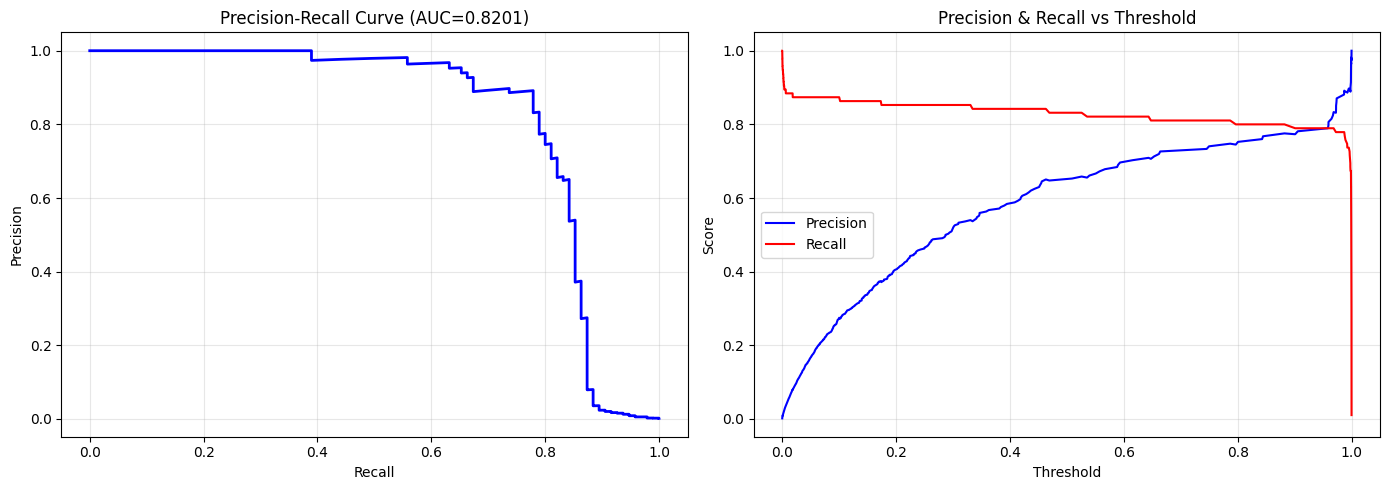

In [29]:
y_probs, y_pred = get_predictions(best_pipeline, X_test, threshold=optimal_threshold)
metrics = evaluate_model(y_test, y_pred, y_probs)

# Plot PR curve
plot_precision_recall_curve(y_test, y_probs)

FEATURE IMPORTANCE

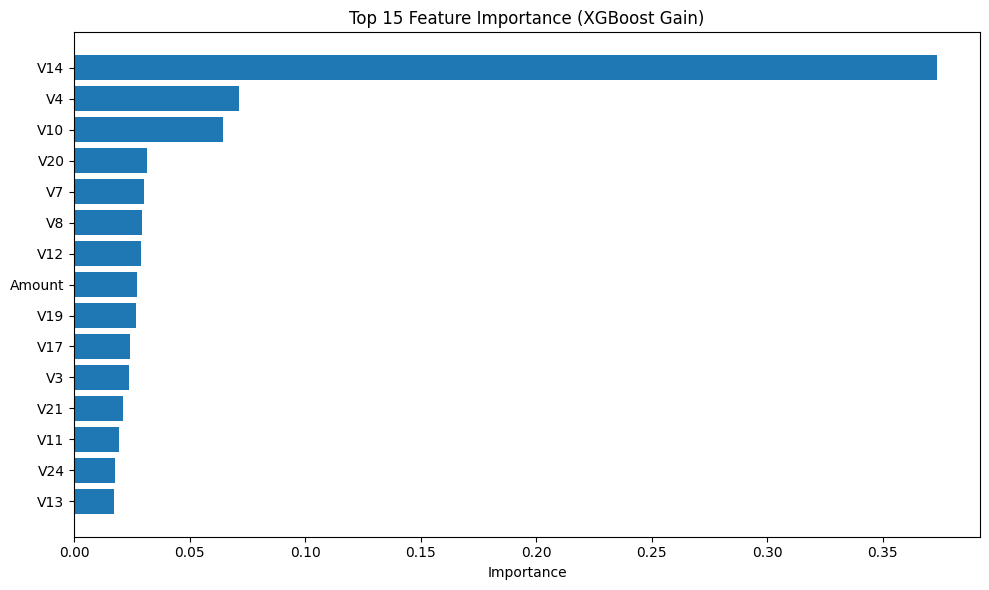


Top 15 Features:
Feature  Importance
    V14    0.373344
     V4    0.071268
    V10    0.064259
    V20    0.031434
     V7    0.030030
     V8    0.029227
    V12    0.028827
 Amount    0.027054
    V19    0.026567
    V17    0.024218
     V3    0.023706
    V21    0.021284
    V11    0.019326
    V24    0.017570
    V13    0.017420


In [30]:
importance_df = get_feature_importance(best_pipeline, X_train)

SHAP EXPLAINABILITY

e:\Projects 2.0\Credit_Card\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Input shape for SHAP: (200, 29)
Model expects: 29 features
SHAP values shape: (200, 29)


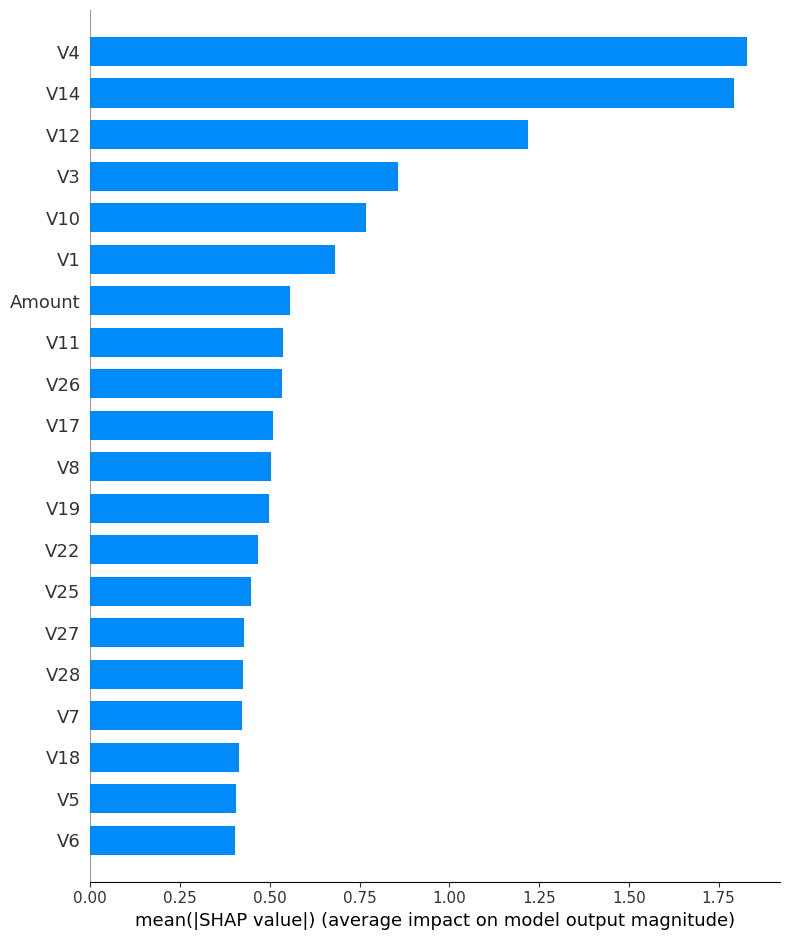

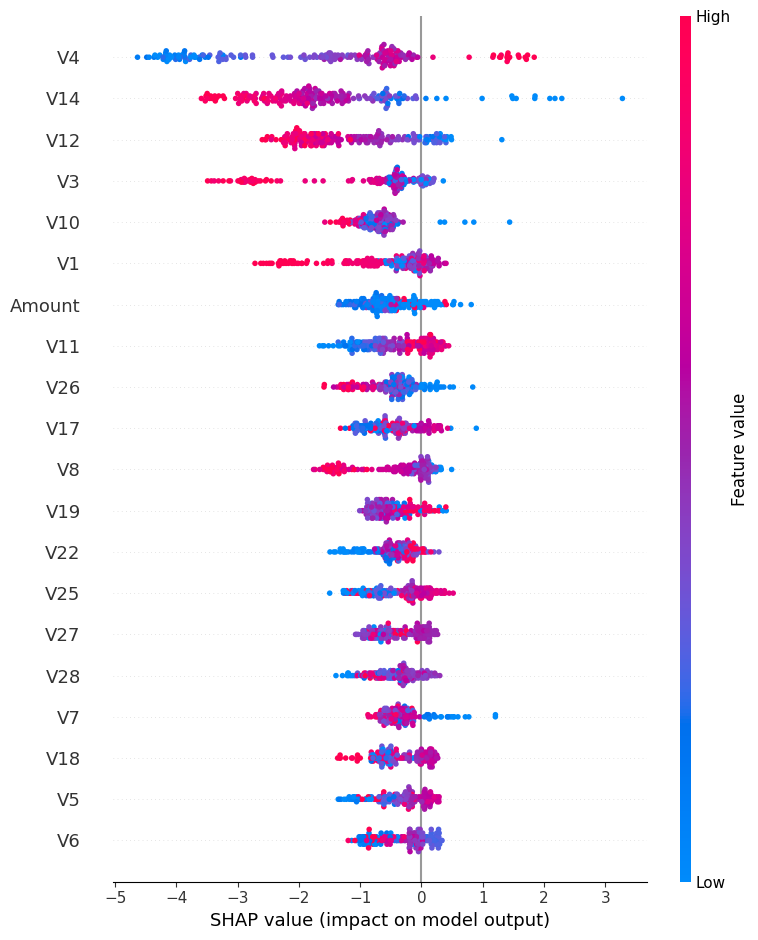

Prediction: 0.0001 probability of fraud

Top 5 reasons:
Feature     Value  SHAP_Value            Direction
     V3  2.639091   -2.769000 Decreases fraud risk
    V12  1.016295   -2.151670 Decreases fraud risk
    V14 -0.164308   -1.905873 Decreases fraud risk
     V8  0.612213   -1.604220 Decreases fraud risk
    V27  0.412917   -0.863937 Decreases fraud risk


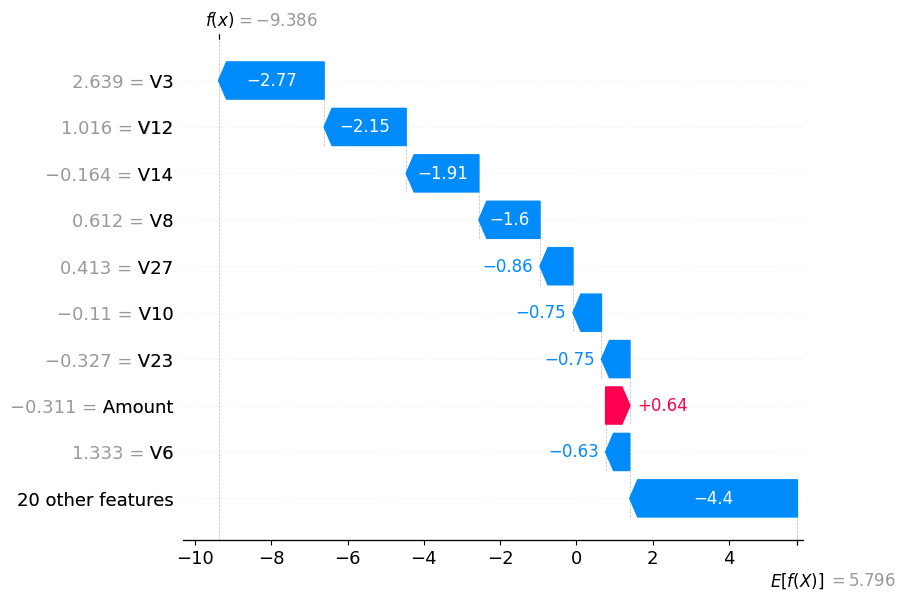

In [31]:
shap_values, X_shap = explain_with_shap(best_pipeline, X_test, n_samples=200)

# Explain a single prediction
explanation = explain_single_prediction(best_pipeline, X_test, sample_idx=0)

SAVE MODEL FOR PRODUCTION

In [32]:
save_model(best_pipeline, metrics, threshold=optimal_threshold)

Model saved: artifacts\fraud_pipeline.pkl
Metadata saved: artifacts\model_metadata.json


'artifacts\\fraud_pipeline.pkl'

PRODUCTION INFERENCE (how to use the saved model)

# Load model
loaded_pipeline = load_model("artifacts/fraud_pipeline.pkl")

# Predict on new data (pass raw data — pipeline handles preprocessing)
sample_data = X_test.iloc[:5]
results = predict_fraud(loaded_pipeline, sample_data, threshold=optimal_threshold)
print("\nProduction Predictions:")
print(results)